In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [4]:
def regression_metrics(y_true, y_pred):

    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = 100 * mae / np.average(y_true)

    return {
        "r2": r2,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "mape": mape
    }

In [5]:
datasets = {
    "7d_no_info": pd.read_csv("qDiario_7d_no_info.csv"),
    "7d_info": pd.read_csv("qDiario_7d_info.csv"),
    "14d_no_info": pd.read_csv("qDiario_14d_no_info.csv"),
    "14d_info": pd.read_csv("qDiario_14d_info.csv")
}

In [6]:
def prepare_data(df, target_col="m3(t)"):

    df = df.dropna().copy()

    if "Fecha" in df.columns:
        df["Fecha"] = pd.to_datetime(df["Fecha"])
        dates = df["Fecha"]
    else:
        dates = pd.to_datetime(df.index)

    df_numeric = df.select_dtypes(include=[np.number])

    X = df_numeric.drop(columns=[target_col])
    y = df_numeric[target_col]

    split_idx = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    dates_train = dates.iloc[:split_idx]
    dates_test = dates.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y, dates_train, dates_test

In [7]:
def reshape_for_cnn(X):
    return X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
def build_cnn_hp(input_shape, filters, kernel):

    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.Conv1D(int(filters), int(kernel), padding="same", activation="relu"),
        layers.MaxPooling1D(2),

        layers.Conv1D(int(filters)//2, int(kernel), padding="same", activation="relu"),

        layers.Flatten(),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [9]:
param_grid = [
    {"filters": 32, "kernel": 2, "batch": 32},
    {"filters": 64, "kernel": 2, "batch": 32},
    {"filters": 32, "kernel": 3, "batch": 32},
    {"filters": 64, "kernel": 3, "batch": 64},
    {"filters": 64, "kernel": 4, "batch": 64},
    {"filters": 128, "kernel": 2, "batch": 64},
    {"filters": 128, "kernel": 3, "batch": 64},
    {"filters": 128, "kernel": 4, "batch": 64},
]

In [10]:
def cross_validate_cnn_ts(X_train, y_train, best_params, n_splits=10):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        print(f"Fold {fold+1}")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        X_tr = reshape_for_cnn(X_tr)
        X_val = reshape_for_cnn(X_val)

        model = build_cnn_hp(
            (X_tr.shape[1], 1),
            best_params["filters"],
            best_params["kernel"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=40,
            batch_size=best_params["batch"],
            verbose=0
        )

        y_pred = model.predict(X_val, verbose=0)

        metrics_dict = regression_metrics(y_val, y_pred)
        fold_metrics.append(metrics_dict)

        print(f"  RMSE: {metrics_dict['rmse']:.4f} | MAE: {metrics_dict['mae']:.4f} | MAPE: {metrics_dict['mape']:.2f}")

    return fold_metrics

In [11]:
def cross_validate_cnn_hp(X_train, y_train, params, n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        X_tr = reshape_for_cnn(X_tr)
        X_val = reshape_for_cnn(X_val)

        model = build_cnn_hp(
            (X_tr.shape[1], 1),
            params["filters"],
            params["kernel"]
        )

        model.fit(
            X_tr, y_tr,
            epochs=80,
            batch_size=params["batch"],
            verbose=0
        )

        y_pred = model.predict(X_val, verbose=0)

        scores.append(regression_metrics(y_val, y_pred)["rmse"])

    return np.mean(scores)

In [12]:
def train_and_predict_train_test_cnn(X_train, y_train, X_test, y_test, scaler_y, best_params):

    X_train_cnn = reshape_for_cnn(X_train)
    X_test_cnn = reshape_for_cnn(X_test)

    model = build_cnn_hp(
        (X_train_cnn.shape[1], 1),
        best_params["filters"],
        best_params["kernel"]
    )

    model.fit(
        X_train_cnn, y_train,
        epochs=100,
        batch_size=best_params["batch"],
        verbose=0
    )

    y_train_pred = model.predict(X_train_cnn, verbose=0)
    y_test_pred = model.predict(X_test_cnn, verbose=0)

    # 🔥 CLAVE: trabajar en escala normalizada
    y_train_true = y_train
    y_test_true = y_test

    metrics_dict = regression_metrics(y_test_true, y_test_pred)

    return metrics_dict, y_train_true, y_train_pred, y_test_true, y_test_pred

In [13]:
def plot_train_test(dates_train, dates_test,
                    y_train_true, y_train_pred,
                    y_test_true, y_test_pred,
                    title):

    plt.figure(figsize=(14,8))
    n_ticks = 10

    # TRAIN
    plt.subplot(2,1,1)
    plt.plot(dates_train, y_train_true, color="gray", label="Real")
    plt.plot(dates_train, y_train_pred, color="red", label="Predicción")
    plt.title(f"{title} - Train (80%)")
    plt.legend(loc="upper right")

    idx = np.linspace(0, len(dates_train)-1, n_ticks, dtype=int)
    plt.xticks(dates_train.iloc[idx], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    # TEST
    plt.subplot(2,1,2)
    plt.plot(dates_test, y_test_true, color="gray", label="Real")
    plt.plot(dates_test, y_test_pred, color="red", label="Predicción")
    plt.title(f"{title} - Test (20%)")
    plt.legend(loc="upper right")

    idx = np.linspace(0, len(dates_test)-1, n_ticks, dtype=int)
    plt.xticks(dates_test.iloc[idx], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

    plt.tight_layout()
    plt.show()

In [14]:
def plot_boxplots(folds_df):

    order = ["7d_no_info", "7d_info", "14d_no_info", "14d_info"]

    palette = {
        "7d_no_info": "#4C72B0",
        "7d_info": "#55A868",
        "14d_no_info": "#C44E52",
        "14d_info": "#8172B2"
    }

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    sns.boxplot(data=folds_df, x="dataset", y="rmse",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("RMSE")

    plt.subplot(1,3,2)
    sns.boxplot(data=folds_df, x="dataset", y="mae",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAE")

    plt.subplot(1,3,3)
    sns.boxplot(data=folds_df, x="dataset", y="mape",
                order=order, hue="dataset", palette=palette, legend=False)
    plt.title("MAPE")

    plt.tight_layout()
    plt.show()

In [15]:
hp_results = []

df_hp = datasets["7d_info"]

X_train, _, y_train, _, _, _, _ = prepare_data(df_hp)

for params in param_grid:

    print(f"Testing: {params}")

    score = cross_validate_cnn_hp(X_train, y_train, params)

    hp_results.append({**params, "rmse": score})

hp_df = pd.DataFrame(hp_results).sort_values("rmse")
display(hp_df)

best_params = hp_df.iloc[0].to_dict()

best_params = {
    "filters": int(best_params["filters"]),
    "kernel": int(best_params["kernel"]),
    "batch": int(best_params["batch"])
}

print("Best params:", best_params)

Testing: {'filters': 32, 'kernel': 2, 'batch': 32}


Testing: {'filters': 64, 'kernel': 2, 'batch': 32}
Testing: {'filters': 32, 'kernel': 3, 'batch': 32}
Testing: {'filters': 64, 'kernel': 3, 'batch': 64}
Testing: {'filters': 64, 'kernel': 4, 'batch': 64}
Testing: {'filters': 128, 'kernel': 2, 'batch': 64}
Testing: {'filters': 128, 'kernel': 3, 'batch': 64}
Testing: {'filters': 128, 'kernel': 4, 'batch': 64}


,filters,kernel,batch,rmse
5,128,2,64,0.103730
0,32,2,32,0.103884
2,32,3,32,0.104245
1,64,2,32,0.104530
6,128,3,64,0.104607
4,64,4,64,0.105397
7,128,4,64,0.105485
3,64,3,64,0.106270


Best params: {'filters': 128, 'kernel': 2, 'batch': 64}



DATASET: 7d_no_info
Fold 1
  RMSE: 0.1031 | MAE: 0.0777 | MAPE: 17.53
Fold 2
  RMSE: 0.0791 | MAE: 0.0615 | MAPE: 27.10
Fold 3
  RMSE: 0.0983 | MAE: 0.0735 | MAPE: 21.80
Fold 4
  RMSE: 0.1298 | MAE: 0.1006 | MAPE: 17.76
Fold 5
  RMSE: 0.0845 | MAE: 0.0623 | MAPE: 15.63
Fold 6
  RMSE: 0.0957 | MAE: 0.0767 | MAPE: 46.51
Fold 7
  RMSE: 0.1365 | MAE: 0.1050 | MAPE: 20.50
Fold 8
  RMSE: 0.0876 | MAE: 0.0645 | MAPE: 18.91
Fold 9
  RMSE: 0.0789 | MAE: 0.0505 | MAPE: 29.67
Fold 10
  RMSE: 0.1468 | MAE: 0.1138 | MAPE: 29.19


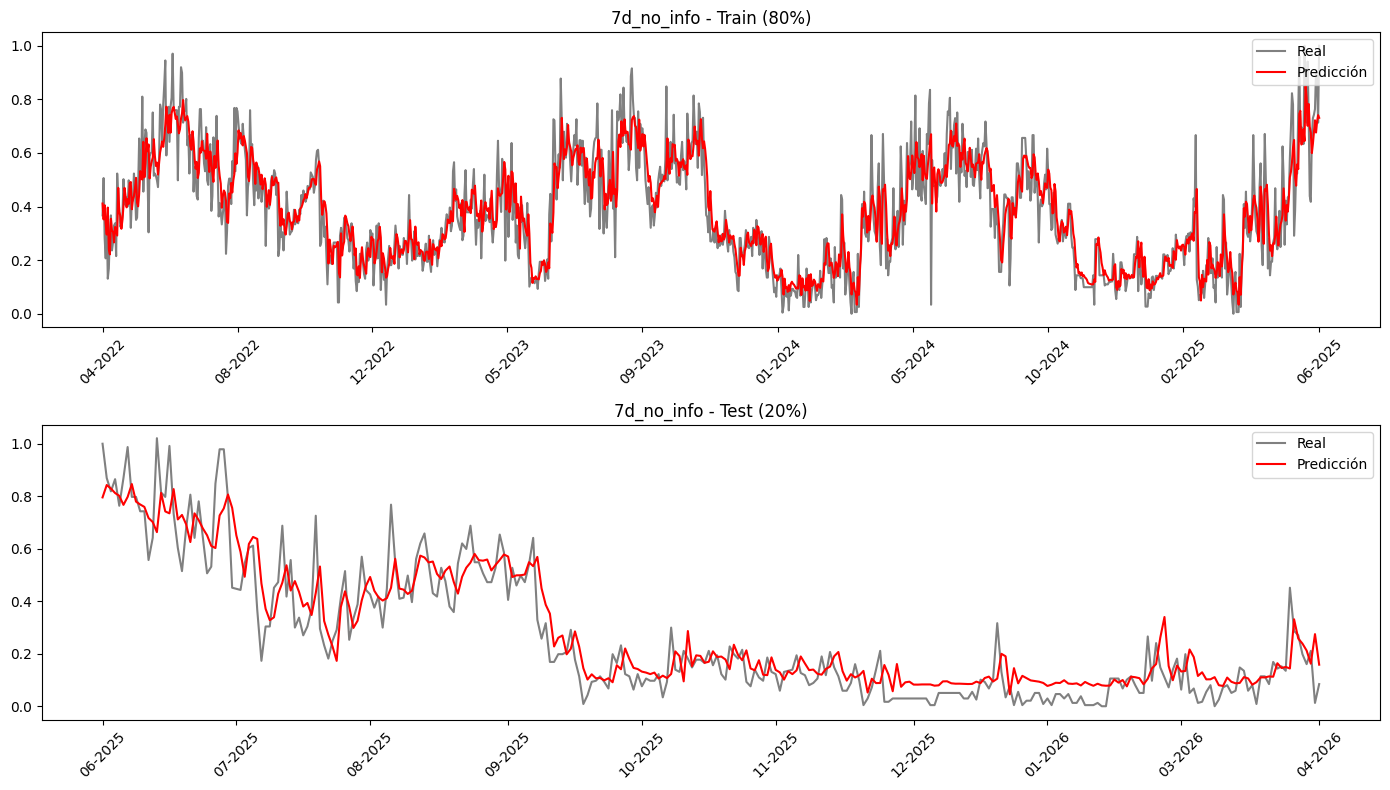


DATASET: 7d_info
Fold 1
  RMSE: 0.1353 | MAE: 0.1091 | MAPE: 24.62
Fold 2
  RMSE: 0.0724 | MAE: 0.0561 | MAPE: 24.74
Fold 3
  RMSE: 0.0977 | MAE: 0.0769 | MAPE: 22.81
Fold 4
  RMSE: 0.1307 | MAE: 0.1011 | MAPE: 17.86
Fold 5
  RMSE: 0.0880 | MAE: 0.0625 | MAPE: 15.67
Fold 6
  RMSE: 0.0946 | MAE: 0.0760 | MAPE: 46.09
Fold 7
  RMSE: 0.1282 | MAE: 0.0942 | MAPE: 18.38
Fold 8
  RMSE: 0.0868 | MAE: 0.0652 | MAPE: 19.14
Fold 9
  RMSE: 0.0749 | MAE: 0.0488 | MAPE: 28.70
Fold 10
  RMSE: 0.1361 | MAE: 0.1053 | MAPE: 27.00


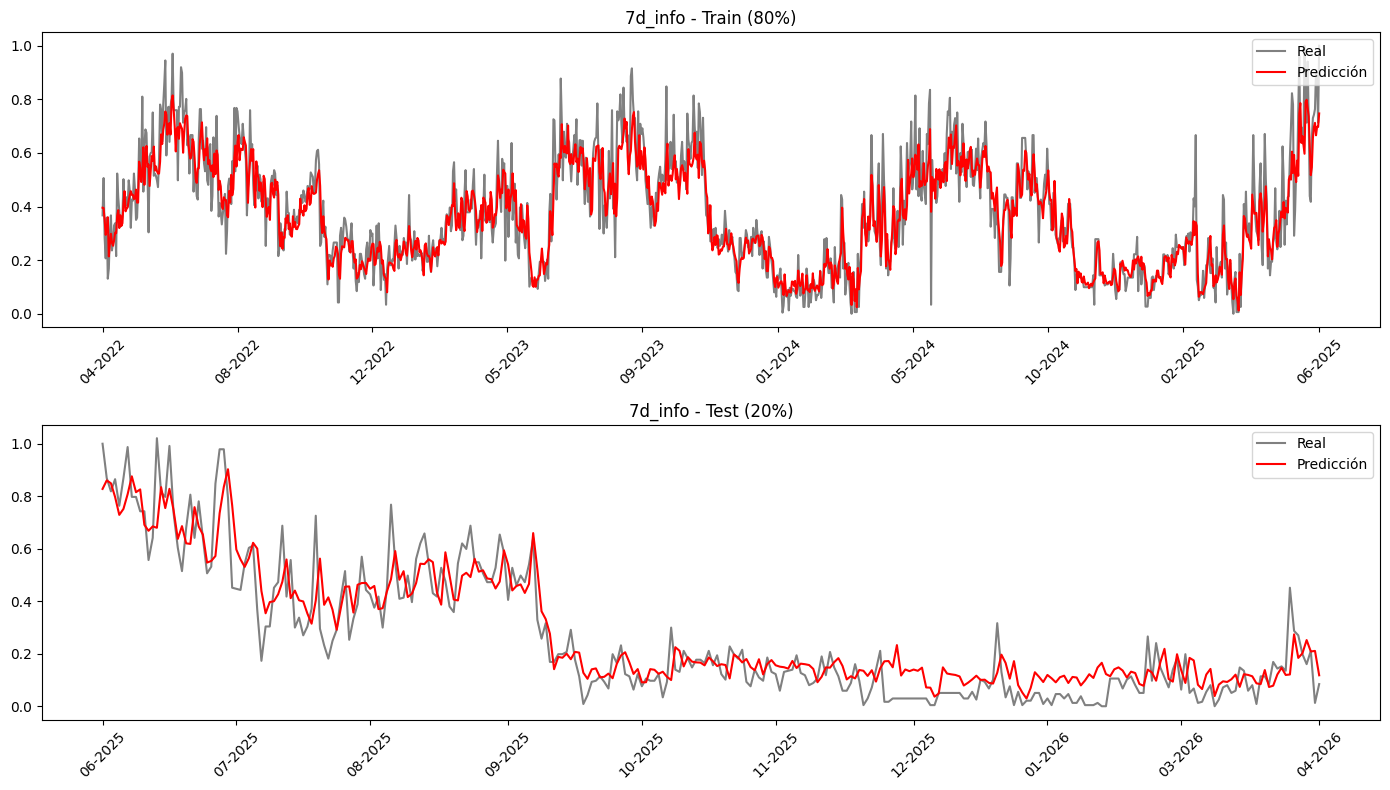


DATASET: 14d_no_info
Fold 1
  RMSE: 0.1077 | MAE: 0.0808 | MAPE: 18.35
Fold 2
  RMSE: 0.0686 | MAE: 0.0526 | MAPE: 23.01
Fold 3
  RMSE: 0.0980 | MAE: 0.0736 | MAPE: 21.78
Fold 4
  RMSE: 0.1208 | MAE: 0.0931 | MAPE: 16.35
Fold 5
  RMSE: 0.0863 | MAE: 0.0605 | MAPE: 15.40
Fold 6
  RMSE: 0.0958 | MAE: 0.0750 | MAPE: 44.96
Fold 7
  RMSE: 0.1331 | MAE: 0.1029 | MAPE: 20.03
Fold 8
  RMSE: 0.0819 | MAE: 0.0607 | MAPE: 18.02
Fold 9
  RMSE: 0.0788 | MAE: 0.0471 | MAPE: 27.62
Fold 10
  RMSE: 0.1407 | MAE: 0.1105 | MAPE: 27.28


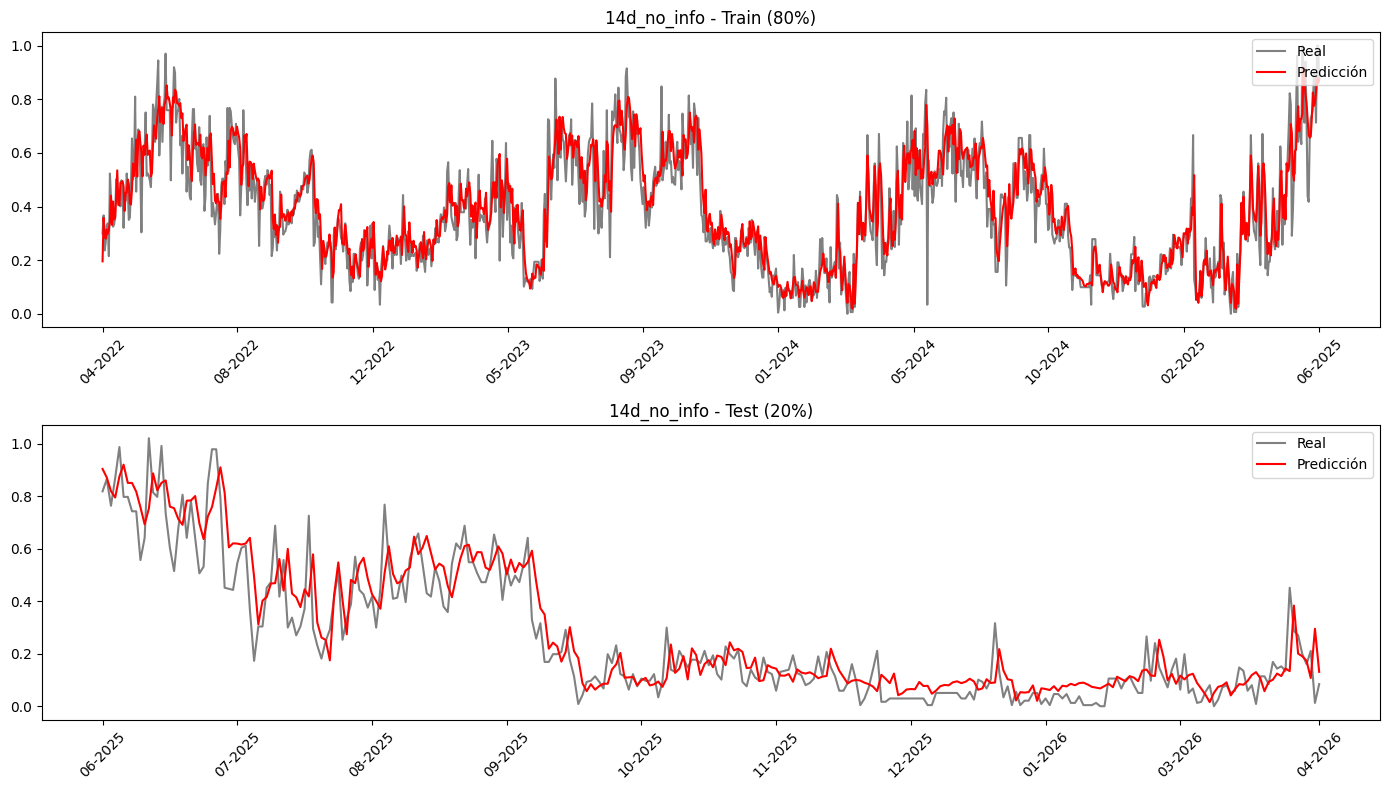


DATASET: 14d_info
Fold 1
  RMSE: 0.1275 | MAE: 0.1002 | MAPE: 22.76
Fold 2
  RMSE: 0.0711 | MAE: 0.0548 | MAPE: 23.98
Fold 3
  RMSE: 0.0997 | MAE: 0.0795 | MAPE: 23.53
Fold 4
  RMSE: 0.1257 | MAE: 0.0987 | MAPE: 17.34
Fold 5
  RMSE: 0.0914 | MAE: 0.0669 | MAPE: 17.03
Fold 6
  RMSE: 0.0985 | MAE: 0.0800 | MAPE: 47.94
Fold 7
  RMSE: 0.1288 | MAE: 0.0966 | MAPE: 18.81
Fold 8
  RMSE: 0.0857 | MAE: 0.0653 | MAPE: 19.39
Fold 9
  RMSE: 0.0713 | MAE: 0.0492 | MAPE: 28.88
Fold 10
  RMSE: 0.1427 | MAE: 0.1102 | MAPE: 27.22


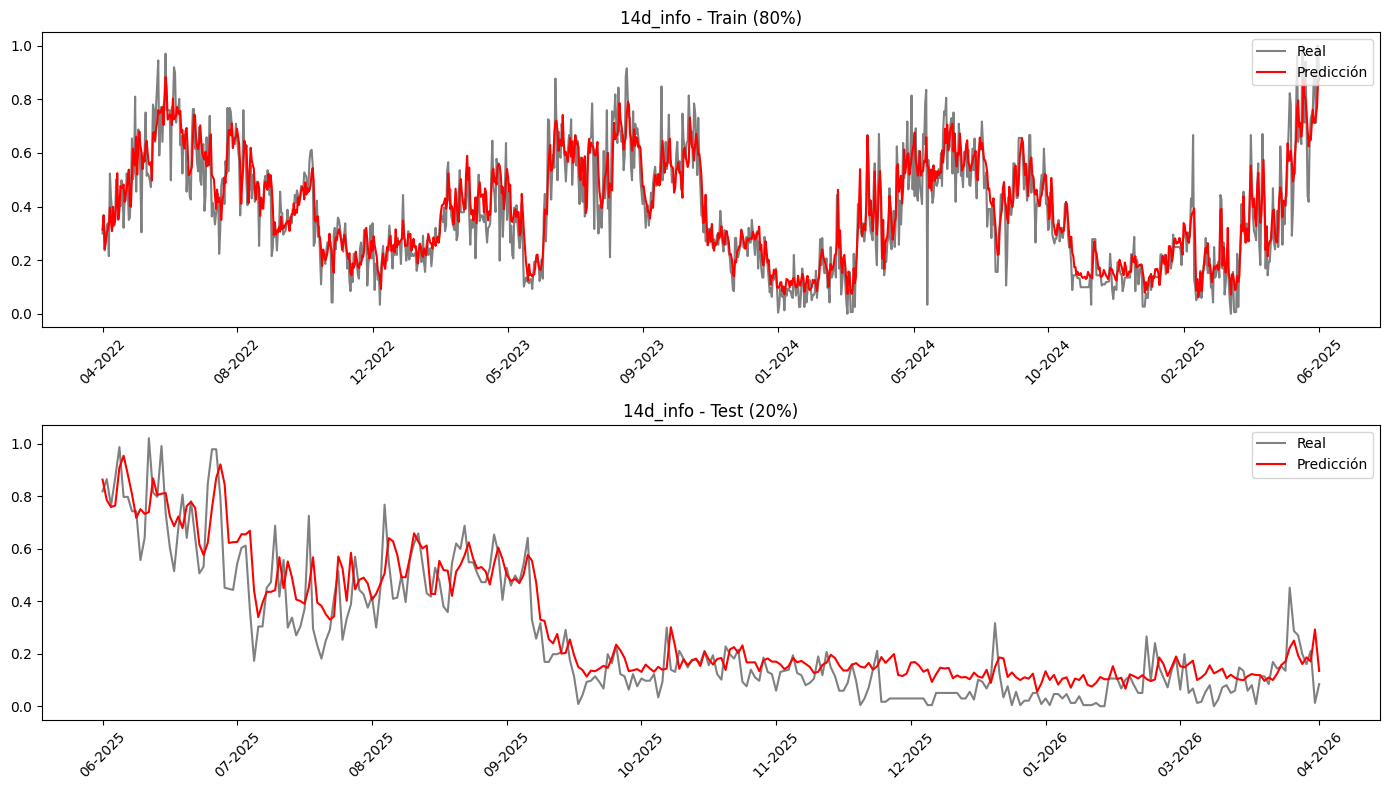

In [16]:
results = []
fold_results = []

for name, df in datasets.items():

    print(f"\n==============================")
    print(f"DATASET: {name}")
    print(f"==============================")

    X_train, X_test, y_train, y_test, scaler_y, dates_train, dates_test = prepare_data(df)

    fold_metrics = cross_validate_cnn_ts(X_train, y_train, best_params)

    for i, f in enumerate(fold_metrics):
        fold_results.append({
            "dataset": name,
            "fold": i+1,
            "rmse": f["rmse"],
            "mae": f["mae"],
            "mape": f["mape"]
        })

    avg_rmse = np.mean([f["rmse"] for f in fold_metrics])
    avg_mae = np.mean([f["mae"] for f in fold_metrics])
    avg_mape = np.mean([f["mape"] for f in fold_metrics])

    test_metrics, y_train_true, y_train_pred, y_test_true, y_test_pred = train_and_predict_train_test_cnn(
        X_train, y_train, X_test, y_test, scaler_y, best_params
    )

    results.append({
        "dataset": name,
        "cv_rmse": avg_rmse,
        "cv_mae": avg_mae,
        "cv_mape": avg_mape,
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_mape": test_metrics["mape"]
    })

    plot_train_test(
        dates_train,
        dates_test,
        y_train_true,
        y_train_pred,
        y_test_true,
        y_test_pred,
        title=name
    )

In [17]:
results_df = pd.DataFrame(results)
folds_df = pd.DataFrame(fold_results)

print("\n===== RESULTADOS FINALES =====")
display(results_df)

print("\n===== RESULTADOS POR FOLD =====")
display(folds_df)


===== RESULTADOS FINALES =====


,dataset,cv_rmse,cv_mae,cv_mape,test_rmse,test_mae,test_mape
0,7d_no_info,0.104034,0.078597,24.458411,0.098710,0.073791,27.833755
1,7d_info,0.104467,0.079528,24.501457,0.097673,0.073851,27.856326
2,14d_no_info,0.101172,0.075672,23.282695,0.098427,0.072970,28.011667
3,14d_info,0.104235,0.080141,24.686581,0.104397,0.081668,31.350641



===== RESULTADOS POR FOLD =====


,dataset,fold,rmse,mae,mape
0,7d_no_info,1,0.103141,0.077676,17.527778
1,7d_no_info,2,0.079080,0.061483,27.098725
2,7d_no_info,3,0.098272,0.073453,21.796919
3,7d_no_info,4,0.129809,0.100555,17.759507
4,7d_no_info,5,0.084512,0.062309,15.630928
5,7d_no_info,6,0.095675,0.076670,46.506384
6,7d_no_info,7,0.136524,0.105026,20.495397
7,7d_no_info,8,0.087574,0.064469,18.908842
8,7d_no_info,9,0.078910,0.050500,29.673990
9,7d_no_info,10,0.146840,0.113828,29.185642


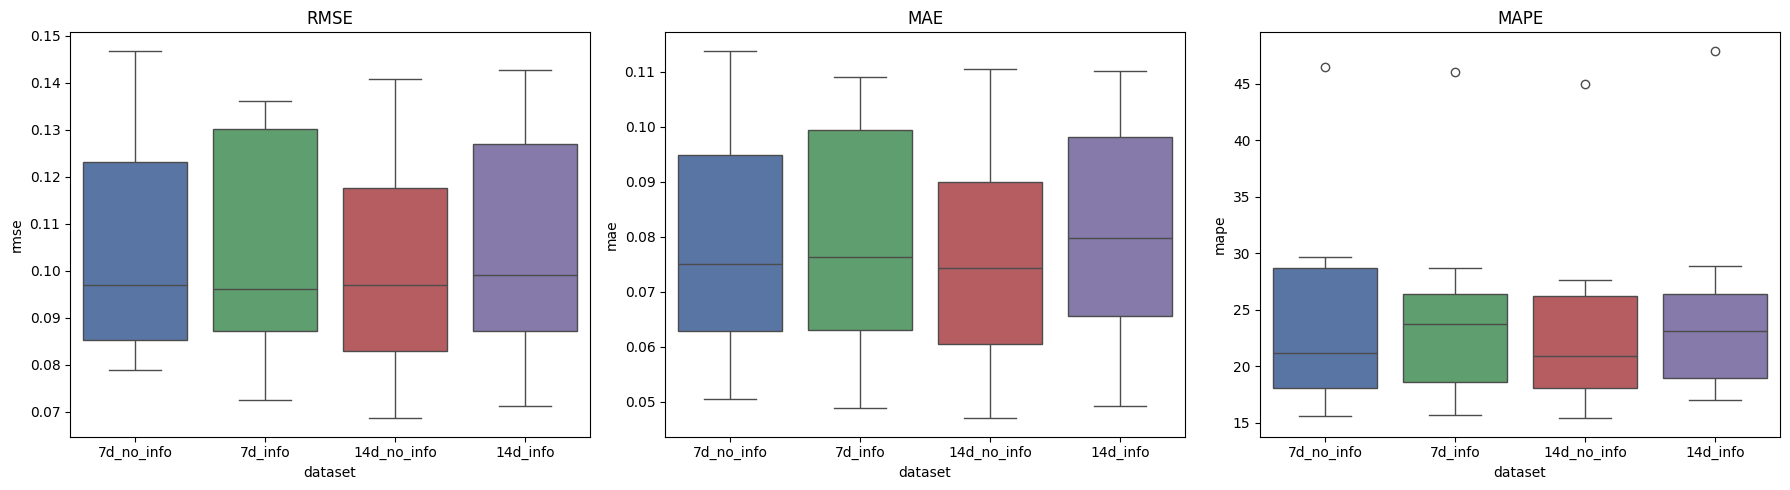

In [18]:
plot_boxplots(folds_df)

In [19]:
folds_df.to_csv("folds_cnn.csv", index=False)
results_df.to_csv("results_cnn.csv")